# Ejercicio de programación Regresión Polinomial

In [ ]:
#from google.colab import drive
#drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [50]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 2 Regresión Polinomial - Dataset SkillCraft1

Se implementa la regresión polinomial para predecir la **Liga/Habilidad (LeagueIndex)** de un jugador de StarCraft basado en su **Edad (Age)**.

El dataset SkillCraft1 contiene 3395 registros de jugadores profesionales con sus características de juego. 
- **Variable independiente (X):** Age (Edad del jugador)
- **Variable dependiente (y):** LeagueIndex (Liga: 1=Bronze, 2=Silver, ..., 7=GrandMaster)

<a id="section4"></a>
### 2.1 Normalización de características

Al visualizar los datos se puede observar que las características tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger más rápidamente.

In [52]:
# Cargar datos - Dataset SkillCraft1 (StarCraft)
# Objetivo: Predecir LeagueIndex (Liga/Habilidad) basado en Age (Edad)
data = pd.read_csv('SkillCraft1_Dataset.csv')
print("Dataset cargado (original):")
print(f"Filas: {len(data)}")

# Limpiar datos: remover filas con valores faltantes ('?') en Age o LeagueIndex
data_clean = data[(data['Age'] != '?') & (data['LeagueIndex'] != '?')].copy()
print(f"Filas después de limpiar: {len(data_clean)}")
print("\nPrimeras 5 filas:")
print(data_clean.head())
print("\nDimensiones:", data_clean.shape)

# Seleccionar variables - Convertir a numpy array correctamente
# X = Age (columna 'Age')
# y = LeagueIndex (columna 'LeagueIndex' - valores 1 a 7, donde 7 es el mejor)
X = np.array(data_clean['Age'].values, dtype=float).reshape(-1, 1)  # Asegurar que es float y 2D
y = np.array(data_clean['LeagueIndex'].values, dtype=float)  # Asegurar que es float
m = y.size

print("\nPrimeros 20 datos (Age, LeagueIndex):")
print('{:>8s}{:>15s}'.format('Age', 'LeagueIndex'))
print('-'*26)
for i in range(min(20, len(X))):
    print('{:8.1f}{:15.0f}'.format(float(X[i, 0]), float(y[i])))

Dataset cargado (original):
Filas: 3395
Filas después de limpiar: 3340

Primeras 5 filas:
   GameID  LeagueIndex Age HoursPerWeek TotalHours       APM  SelectByHotkeys  \
0      52            5  27           10       3000  143.7180         0.003515   
1      55            5  23           10       5000  129.2322         0.003304   
2      56            4  30           10        200   69.9612         0.001101   
3      57            3  19           20        400  107.6016         0.001034   
4      58            3  32           10        500  122.8908         0.001136   

   AssignToHotkeys  UniqueHotkeys  MinimapAttacks  MinimapRightClicks  \
0         0.000220              7        0.000110            0.000392   
1         0.000259              4        0.000294            0.000432   
2         0.000336              4        0.000294            0.000461   
3         0.000213              1        0.000053            0.000543   
4         0.000327              2        0.000000         

La desviación estándar es una forma de medir cuánta variación hay en el rango de valores de una característica en particular (la mayoría de los puntos caeran en un rango de ± 2 en relación a la desviaciones estándar de la media); esta es una alternativa a tomar el rango de valores (max-min). En `numpy`, se puede usar la función `std` para calcular la desviacion estandar.

Por ejemplo, la caracteristica`X[:, 0]` contiene todos los valores de $x_1$ (edades) en el conjunto de entrenamiento, entonces `np.std(X[:, 0])` calcula la desviacion estandar de las edades.
En el momento en que se llama a la función `featureNormalize`, la columna adicional de unos correspondiente a $ x_0 = 1 $ aún no se ha agregado a $ X $.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normalize una caracteristica, es importante almacenar los valores usados para la normalización - el valor de la media y el valor de la desviación estandar usado para los calculos. Despues de aprender los parametros del modelo, se deseara predecir la capacidad adquisitiva que no se han visto antes. Dado un nuevo valor de x (edad), primero se debe normalizar x usando la media y la desviacion estandar que se empleo anteriormente en el conjunto de entrenamiento para entrenar el modelo.
</div>
<a id="featureNormalize"></a>

In [53]:
def plotData(x, y, xlabel='X', ylabel='Y'):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure(figsize=(10, 6))  # abre una nueva figura con tamaño adecuado

    # Convierte a array si x es DataFrame
    if isinstance(x, pd.DataFrame) or isinstance(x, pd.Series):
        x = x.values.flatten()
    
    pyplot.plot(x, y, 'ro', ms=10, mec='k')
    pyplot.ylabel(ylabel)
    pyplot.xlabel(xlabel)
    pyplot.grid(True, alpha=0.3)
    pyplot.show()  # Muestra la gráfica


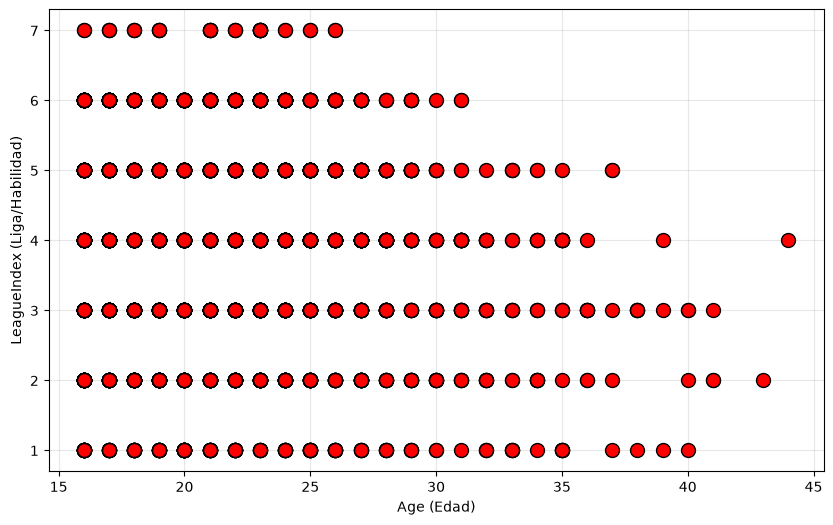

In [54]:
plotData(X, y, xlabel='Age (Edad)', ylabel='LeagueIndex (Liga/Habilidad)')

In [55]:
X = np.concatenate([X, X * X], axis=1)

In [29]:
print(X)

[[ 1.         -1.74772386 -1.13113889 ...  1.27947519  1.27947519
   0.54291956]
 [ 1.         -1.74662074 -1.13112698 ...  1.27944825  1.27944825
   0.54291955]
 [ 1.         -1.74625303 -1.13112286 ...  1.27943893  1.27943893
   0.54291955]
 ...
 [ 1.          1.9440712   2.64827572 ...  7.01336427  7.01336427
  15.05586895]
 [ 1.          1.94480661  2.64977389 ...  7.02130167  7.02130167
  15.08429335]
 [ 1.          1.94517432  2.65052309 ...  7.02527264  7.02527264
  15.09852195]]


In [56]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [57]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

#print(X)
#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)
#print(X_norm)

In [32]:
print(X_norm)

[[        nan -1.74772386 -1.13113889 ...  0.23845943  0.23845943
  -0.21786769]
 [        nan -1.74662074 -1.13112698 ...  0.23843644  0.23843644
  -0.21786769]
 [        nan -1.74625303 -1.13112286 ...  0.23842849  0.23842849
  -0.2178677 ]
 ...
 [        nan  1.9440712   2.64827572 ...  5.13084325  5.13084325
   6.69973918]
 [        nan  1.94480661  2.64977389 ...  5.13761576  5.13761576
   6.71328769]
 [        nan  1.94517432  2.65052309 ...  5.14100395  5.14100395
   6.72006976]]


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

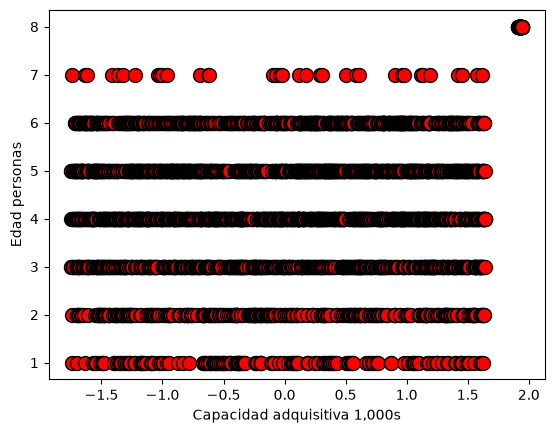

In [ ]:
plotData(X_norm[:,1], y, xlabel='Age Normalizado', ylabel='LeagueIndex')

In [58]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
#X_norm = np.concatenate([X_norm, X_norm * X_norm], axis=1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [35]:
print(X)

[[ 1.                 nan -1.74772386 ...  0.23845943  0.23845943
  -0.21786769]
 [ 1.                 nan -1.74662074 ...  0.23843644  0.23843644
  -0.21786769]
 [ 1.                 nan -1.74625303 ...  0.23842849  0.23842849
  -0.2178677 ]
 ...
 [ 1.                 nan  1.9440712  ...  5.13084325  5.13084325
   6.69973918]
 [ 1.                 nan  1.94480661 ...  5.13761576  5.13761576
   6.71328769]
 [ 1.                 nan  1.94517432 ...  5.14100395  5.14100395
   6.72006976]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En el ejemplo anterior se implemento el descenso por el gradiente para un problema de regresion univariable. La unica diferencia es que ahora existe una caracteristica adicional en la matriz $X$. La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la funcion de costo y función de descenso por el gradiente de la regresión lineal multiple es similar al de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

Se puede utilizar `shape`, propiedad de los arrays `numpy`, para identificar cuantas caracteristicas estan consideradas en el dataset.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En el caso de multivariables, la función de costo puede se escrita considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numericos computacional como `numpy`.
</div>

<a id="computeCostMulti"></a>

In [59]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [60]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        # Gradiente: X.T @ (X @ theta - y) / m
        error = np.dot(X, theta) - y
        theta = theta - (alpha / m) * X.T.dot(error)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


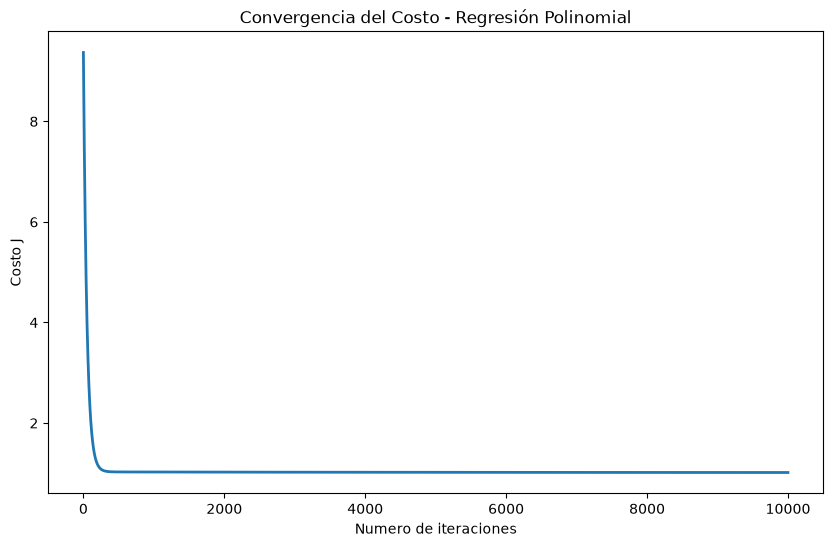

theta calculado por el descenso por el gradiente: [ 4.12125749  0.65160306 -0.84954967]

Predicción: Liga estimada para un jugador de 24 años (usando descenso por gradiente): 4.11
(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)


In [61]:
# Elegir algún valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 10000

# Inicializa theta y ejecuta el descenso por el gradiente
# Usa X.shape[1] para que theta tenga el número correcto de elementos
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(10, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo - Regresión Polinomial')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Predicción: ¿Cuál es la liga estimada para un jugador de 24 años?
edad = 24
X_array = [1, edad, edad**2]
# Normalizar usando la media y desviación estándar calculadas
X_array[1:3] = (np.array(X_array[1:3]) - mu) / sigma
league_pred = np.dot(X_array, theta)

print('\nPredicción: Liga estimada para un jugador de {} años (usando descenso por gradiente): {:.2f}'.format(edad, league_pred))
print('(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)')

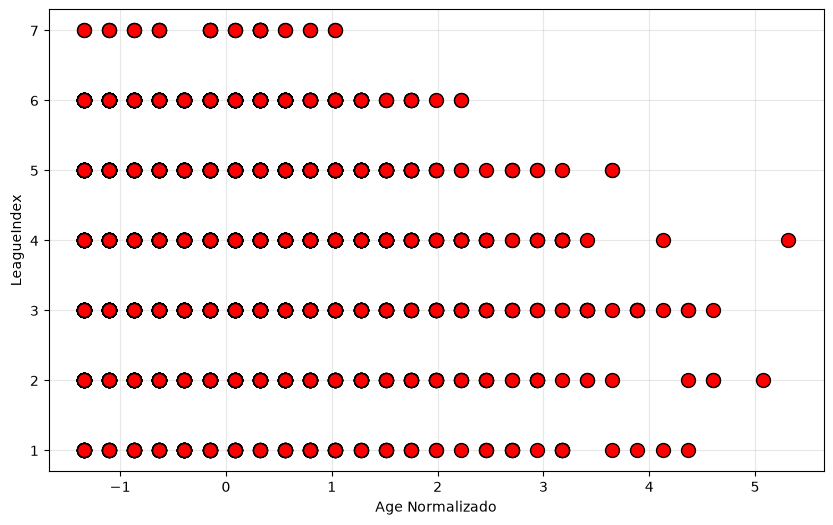

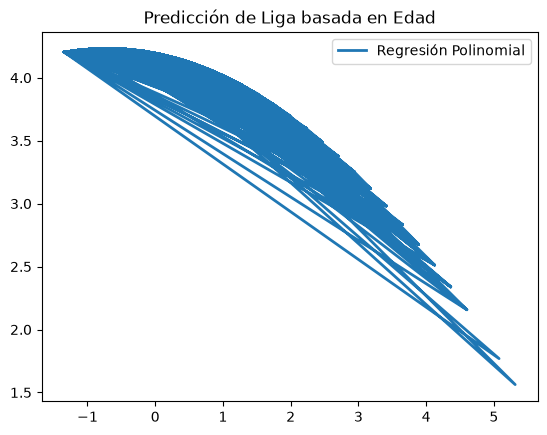

In [62]:
plotData(X[:, 1], y, xlabel='Age Normalizado', ylabel='LeagueIndex')
pyplot.plot(X[:, 1], np.dot(X, theta), '-', linewidth=2, label='Regresión Polinomial')
pyplot.legend()
pyplot.title('Predicción de Liga basada en Edad')
pyplot.show()

In [63]:
# Predicción: ¿Cuál es la liga estimada para un jugador de 30 años?
edad = 30
X_array = [1, edad, edad**2]
X_array[1:3] = (np.array(X_array[1:3]) - mu) / sigma

In [64]:
league_prediction = np.dot(X_array, theta)
print('Liga estimada para un jugador de 30 años: {:.2f}'.format(league_prediction))
print('(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)')

Liga estimada para un jugador de 30 años: 3.70
(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [69]:
# Cargar datos nuevamente para usar Ecuación Normal (sin normalización)
# usando el mismo dataset SkillCraft1
data = pd.read_csv('SkillCraft1_Dataset.csv')

# Limpiar datos: remover filas con valores faltantes
data_clean = data[(data['Age'] != '?') & (data['LeagueIndex'] != '?')].copy()

X = np.array(data_clean['Age'].values, dtype=float).reshape(-1, 1)
y = np.array(data_clean['LeagueIndex'].values, dtype=float)
m = y.size
X_original = X.copy()
# Crear características polinómicas
X = np.concatenate([X, X * X], axis=1)
# Agregar término de intersección
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [66]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [70]:
# Calcula los parámetros con la ecuación de la normal
theta = normalEqn(X, y)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)))

# Predicción: ¿Cuál es la liga estimada para un jugador de 25 años?
edad = 25
X_array = [1, edad, edad**2]
league_pred = np.dot(X_array, theta)

print('\nPredicción para un jugador de {} años (usando ecuación normal): {:.2f}'.format(edad, league_pred))
print('(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)')

Theta calculado a partir de la ecuación de la normal: [ 1.58860573  0.25785587 -0.00627033]

Predicción para un jugador de 25 años (usando ecuación normal): 4.12
(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)


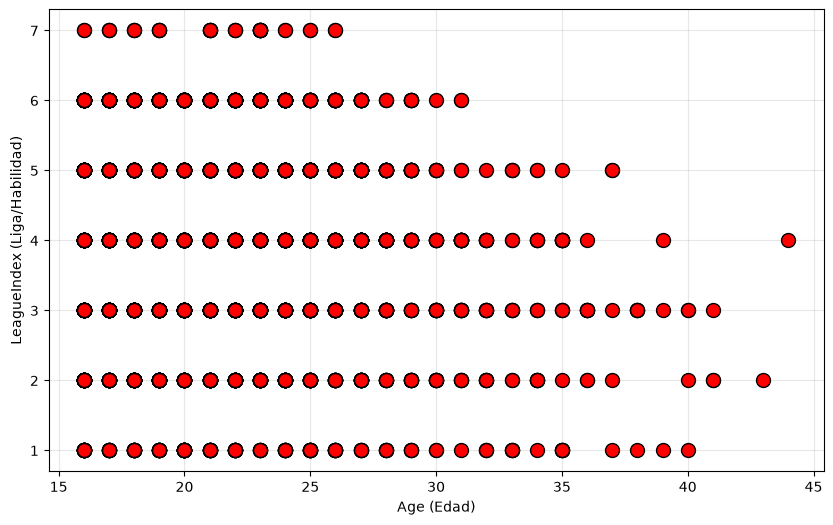

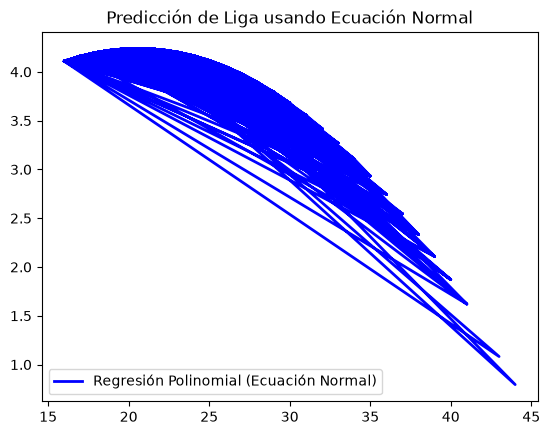

In [71]:
plotData(X[:, 1], y, xlabel='Age (Edad)', ylabel='LeagueIndex (Liga/Habilidad)')
pyplot.plot(X[:, 1], np.dot(X, theta), '-', linewidth=2, color='blue', label='Regresión Polinomial (Ecuación Normal)')
pyplot.legend()
pyplot.title('Predicción de Liga usando Ecuación Normal')
pyplot.show()